# Palmer Penguins: Initial Static Exploratory Data Analysis

This notebook contains the static visualization prototypes referenced in the report. Before migrating to the Plotly and Streamlit-driven interactive dashboard (`app.py`), the initial workflow relied on static plots generated by `seaborn` and `matplotlib`.

These early iterations made it difficult to dynamically filter across islands/species or simultaneously observe ML clusters and physical distributions.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = sns.load_dataset('penguins')
df = df.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex'])
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']

# Define global color palette for static plots
species_palette = {'Adelie': '#7F3C8D', 'Chinstrap': '#11A579', 'Gentoo': '#3969AC'}

sns.set_theme(style="whitegrid")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,2.090909
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,2.270115
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2.238889
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.901554
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1.907767


## 1. Static Distributions and Relationships
Static plots representing body mass distribution and the relationship between flipper length and body mass.

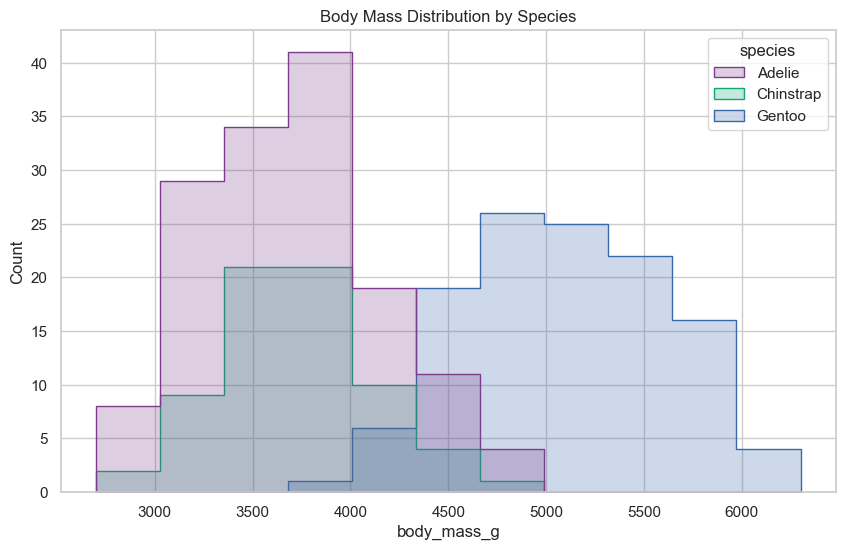

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='body_mass_g', hue='species', element='step', palette=species_palette)
plt.title('Body Mass Distribution by Species')
plt.show()

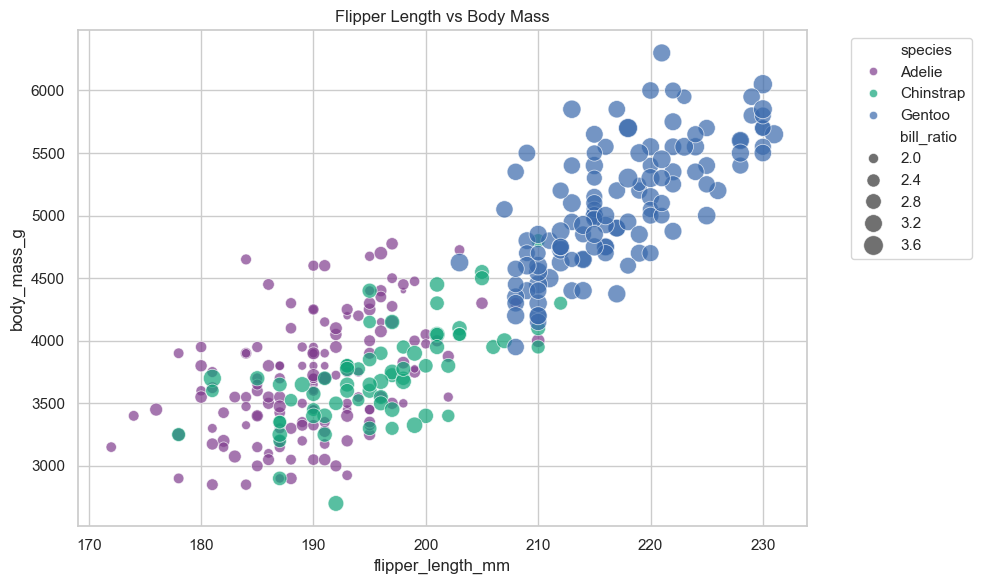

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species', 
                size='bill_ratio', sizes=(20, 200), alpha=0.7, palette=species_palette)
plt.title('Flipper Length vs Body Mass')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 2. Static Machine Learning View (PCA & K-Means)
A static rendering of the Principal Component Analysis and K-Means clusters.

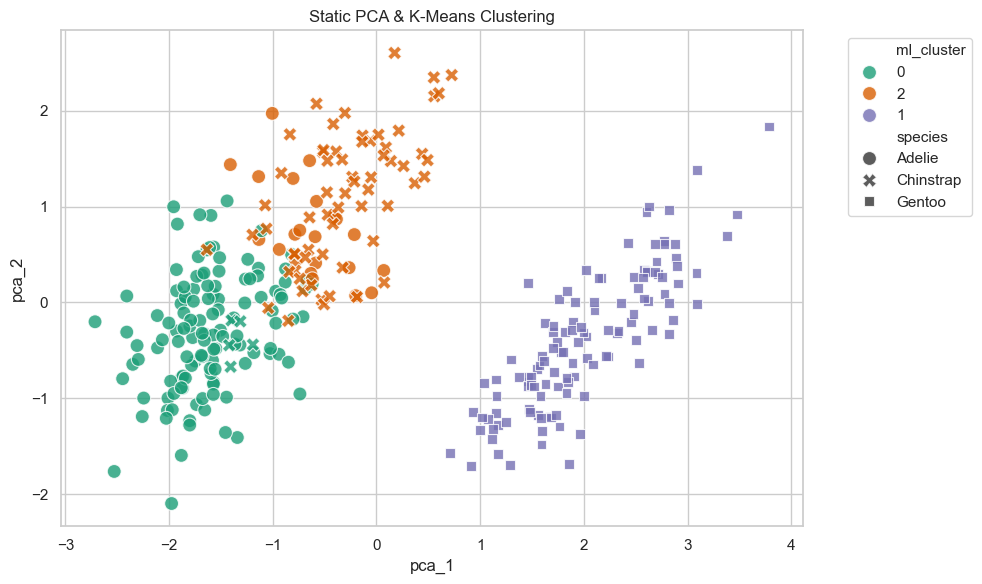

In [4]:
# Preprocessing for ML
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X_scaled = StandardScaler().fit_transform(df[features])

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['ml_cluster'] = kmeans.fit_predict(X_scaled).astype(str)

# PCA for 2D visualization
pca = PCA(n_components=2)
pca_res = pca.fit_transform(X_scaled)
df['pca_1'] = pca_res[:, 0]
df['pca_2'] = pca_res[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='ml_cluster', style='species', 
                palette='Dark2', s=100, alpha=0.8)
plt.title('Static PCA & K-Means Clustering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()